## Advanced CNNs and Computer Vision

**Topics Covered:**
- Advanced CNN Architectures
- Transfer Learning
- Image Data Augmentation
- Computer Vision Tasks
- Object Detection with YOLO
- Real-World Applications

---

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import os

# TensorFlow and Keras
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"     # hide INFO + WARNING
# os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # optional: disable oneDNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Scikit-learn
from sklearn.metrics import classification_report, confusion_matrix

# Visualization
import warnings
warnings.filterwarnings('ignore')

# Configuration
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 100

print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
OpenCV version: 4.13.0
GPU Available: False


## PART 1: Advanced CNN Architectures

### 1.1 Understanding CNN Architecture Evolution

In [3]:
# Load CIFAR-10 for demonstration
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Use subset for faster training
X_train_subset = X_train[:10000]
y_train_subset = y_train_cat[:10000]
X_test_subset = X_test[:2000]
y_test_subset = y_test_cat[:2000]

print(f"Training subset: {X_train_subset.shape}")
print(f"Test subset: {X_test_subset.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step
Training subset: (10000, 32, 32, 3)
Test subset: (2000, 32, 32, 3)


### 1.2 VGG-Style Architecture

In [4]:
# Build VGG-style CNN (simplified)
def build_vgg_style():
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Classifier
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

vgg_model = build_vgg_style()
vgg_model.summary()

print(f"\nTotal parameters: {vgg_model.count_params():,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,248,202 (12.39 MB)

 Trainable params: 3,248,202 (12.39 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 3,248,202


### 1.3 ResNet-Style with Skip Connections

In [5]:
# Build ResNet-style block
def residual_block(x, filters, kernel_size=3):
    """A residual block with skip connection"""
    # Main path
    fx = layers.Conv2D(filters, kernel_size, padding='same')(x)
    fx = layers.BatchNormalization()(fx)
    fx = layers.Activation('relu')(fx)
    fx = layers.Conv2D(filters, kernel_size, padding='same')(fx)
    fx = layers.BatchNormalization()(fx)
    
    # Skip connection
    out = layers.Add()([x, fx])
    out = layers.Activation('relu')(out)
    return out

# Build ResNet-style model
def build_resnet_style():
    inputs = keras.Input(shape=(32, 32, 3))
    
    # Initial conv
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Residual blocks
    x = residual_block(x, 32)
    x = residual_block(x, 32)
    
    # Downsample
    x = layers.Conv2D(64, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    
    # Global pooling and classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    return keras.Model(inputs, outputs)

resnet_model = build_resnet_style()
resnet_model.summary()

print(f"\nTotal parameters: {resnet_model.count_params():,}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │      9,248 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ activation[0][0], │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_3[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ activation_2[0][

 Total params: 215,626 (842.29 KB)

 Trainable params: 214,666 (838.54 KB)

 Non-trainable params: 960 (3.75 KB)


Total parameters: 215,626


### 1.4 Comparing Architecture Performance

In [6]:
# Train both models for comparison
models_to_compare = {
    'VGG-Style': vgg_model,
    'ResNet-Style': resnet_model
}

histories = {}

for name, model in models_to_compare.items():
    print(f"\nTraining {name}...")
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        X_train_subset, y_train_subset,
        validation_split=0.2,
        epochs=15,
        batch_size=128,
        verbose=1
    )
    
    histories[name] = history
    
    # Evaluate
    test_loss, test_acc = model.evaluate(X_test_subset, y_test_subset, verbose=0)
    print(f"{name} Test Accuracy: {test_acc:.4f}")




Training VGG-Style...
Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 350ms/step - accuracy: 0.2025 - loss: 2.1183 - val_accuracy: 0.2740 - val_loss: 1.9550
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 347ms/step - accuracy: 0.3179 - loss: 1.8097 - val_accuracy: 0.3275 - val_loss: 1.8308
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 359ms/step - accuracy: 0.3938 - loss: 1.6184 - val_accuracy: 0.4320 - val_loss: 1.5565
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 355ms/step - accuracy: 0.4544 - loss: 1.4635 - val_accuracy: 0.4770 - val_loss: 1.4282
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 368ms/step - accuracy: 0.5146 - loss: 1.3371 - val_accuracy: 0.5320 - val_loss: 1.3128
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 376ms/step - accuracy: 0.5514 - loss: 1.2299 - val_accuracy: 0.5510 - val_loss: 1.2387
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 402ms/step - accuracy: 0.5813 - loss: 1.1567 - val_accuracy: 0.5475 - val_loss: 1.2493
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 400ms/step - accuracy: 0.6196 - 

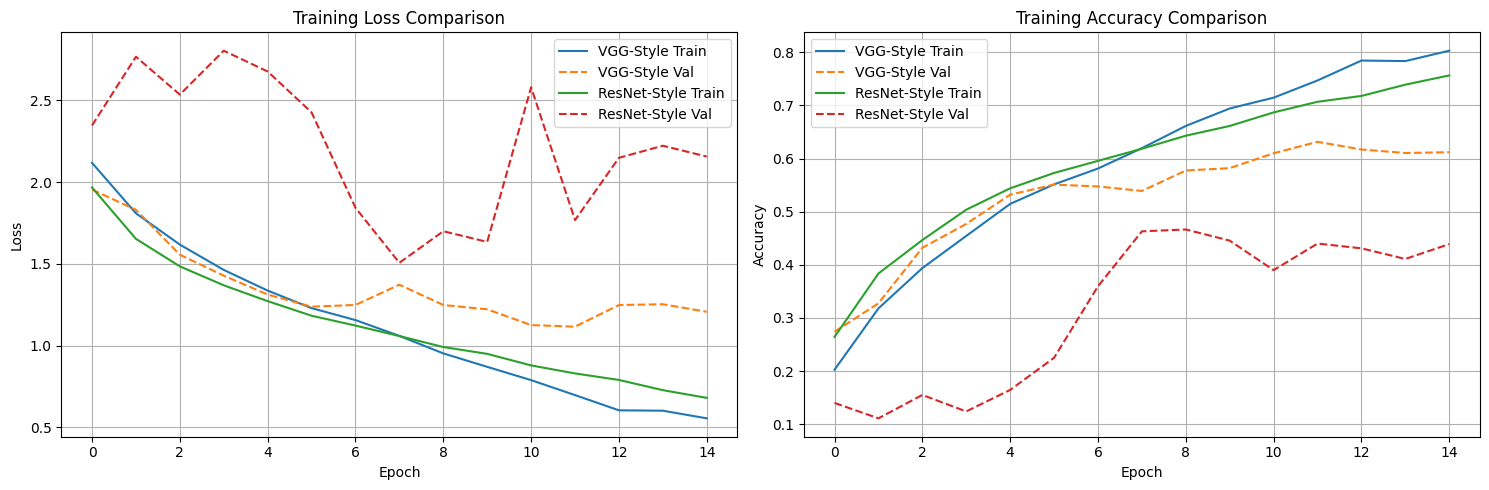

In [7]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, history in histories.items():
    axes[0].plot(history.history['loss'], label=f'{name} Train')
    axes[0].plot(history.history['val_loss'], label=f'{name} Val', linestyle='--')
    
    axes[1].plot(history.history['accuracy'], label=f'{name} Train')
    axes[1].plot(history.history['val_accuracy'], label=f'{name} Val', linestyle='--')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy Comparison')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## PART 2: Transfer Learning

### 2.1 Understanding Transfer Learning

In [8]:
# Load pre-trained model (without top classification layer)
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers
base_model.trainable = False

print("Base model loaded!")
print(f"Total layers: {len(base_model.layers)}")
print(f"Trainable: {base_model.trainable}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model loaded!
Total layers: 154
Trainable: False


### 2.2 Build Transfer Learning Model

In [9]:
# Resize CIFAR-10 images for pre-trained model
def resize_images(images, size=(96, 96)):
    resized = []
    for img in images:
        img_resized = cv2.resize(img, size)
        resized.append(img_resized)
    return np.array(resized)

print("Resizing images for transfer learning...")
X_train_resized = resize_images(X_train_subset[:1000])
X_test_resized = resize_images(X_test_subset[:200])
y_train_transfer = y_train_subset[:1000]
y_test_transfer = y_test_subset[:200]

print(f"Resized training set: {X_train_resized.shape}")
print(f"Resized test set: {X_test_resized.shape}")

Resizing images for transfer learning...
Resized training set: (1000, 96, 96, 3)
Resized test set: (200, 96, 96, 3)


In [10]:
# Build transfer learning model
def build_transfer_model(base_model, num_classes=10):
    inputs = keras.Input(shape=(96, 96, 3))
    
    # Base model
    x = base_model(inputs, training=False)
    
    # Custom top layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return keras.Model(inputs, outputs)

transfer_model = build_transfer_model(base_model)
transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# Train transfer learning model
print("Training transfer learning model...")
history_transfer = transfer_model.fit(
    X_train_resized, y_train_transfer,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

# Evaluate
test_loss, test_acc = transfer_model.evaluate(X_test_resized, y_test_transfer, verbose=0)
print(f"\nTransfer Learning Test Accuracy: {test_acc:.4f}")

Training transfer learning model...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.1350 - loss: 2.9220 - val_accuracy: 0.2850 - val_loss: 2.0281
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.2650 - loss: 2.2742 - val_accuracy: 0.4000 - val_loss: 1.7686
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.3363 - loss: 1.8873 - val_accuracy: 0.4650 - val_loss: 1.5753
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.4137 - loss: 1.6838 - val_accuracy: 0.5250 - val_loss: 1.4615
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.4837 - loss: 1.4762 - val_accuracy: 0.5550 - val_loss: 1.3755
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.5525 - loss: 1.3383 - val_accuracy: 0.5700 - val_loss: 1.3042
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.5987 - loss: 1.2142 - val_accuracy: 0.5850 - val_loss: 1.2427
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.6225 - lo

### 2.3 Fine-Tuning

In [12]:
# Unfreeze the last few layers for fine-tuning
base_model.trainable = True

# Freeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Total layers: {len(base_model.layers)}")
print(f"Trainable layers: {sum([1 for layer in base_model.layers if layer.trainable])}")

# Recompile with lower learning rate
transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune
print("\nFine-tuning...")
history_finetune = transfer_model.fit(
    X_train_resized, y_train_transfer,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=1
)

# Evaluate after fine-tuning
test_loss_ft, test_acc_ft = transfer_model.evaluate(X_test_resized, y_test_transfer, verbose=0)
print(f"\nAfter Fine-tuning Test Accuracy: {test_acc_ft:.4f}")
print(f"Improvement: {(test_acc_ft - test_acc)*100:.2f}%")

Total layers: 154
Trainable layers: 20

Fine-tuning...
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 162ms/step - accuracy: 0.4075 - loss: 1.7609 - val_accuracy: 0.6100 - val_loss: 1.1220
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.4588 - loss: 1.5276 - val_accuracy: 0.6100 - val_loss: 1.1202
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.5175 - loss: 1.4109 - val_accuracy: 0.5900 - val_loss: 1.1216
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.5675 - loss: 1.2977 - val_accuracy: 0.5950 - val_loss: 1.1263
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.5900 - loss: 1.2229 - val_accuracy: 0.6000 - val_loss: 1.1278

After Fine-tuning Test Accuracy: 0.6300
Improvement: 1.50%


## PART 3: Image Data Augmentation

### 3.1 Understanding Data Augmentation

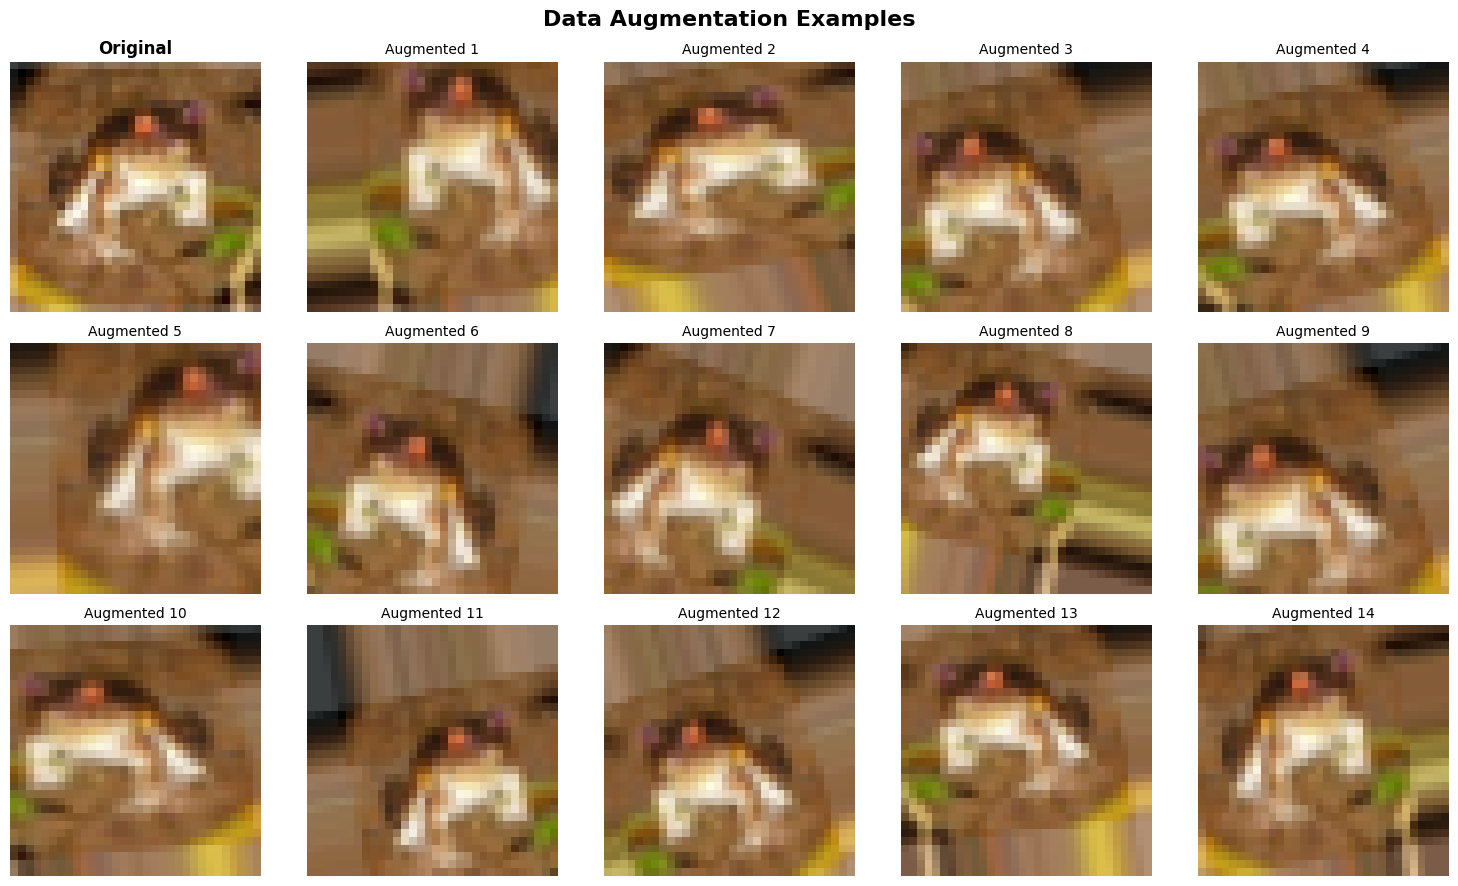

In [13]:
# Visualize data augmentation techniques
sample_image = X_train_subset[0]

# Create augmentation generator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Generate augmented images
sample_image_expanded = np.expand_dims(sample_image, 0)
aug_iter = datagen.flow(sample_image_expanded, batch_size=1)

# Visualize
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.ravel()

# Original
axes[0].imshow(sample_image)
axes[0].set_title('Original', fontweight='bold', fontsize=12)
axes[0].axis('off')

# Augmented versions
for i in range(1, 15):
    batch = next(aug_iter)
    axes[i].imshow(batch[0])
    axes[i].set_title(f'Augmented {i}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Training with Data Augmentation

In [14]:
# Build simple CNN
model_aug = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train without augmentation
print("Training WITHOUT augmentation...")
history_no_aug = model_aug.fit(
    X_train_subset, y_train_subset,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=1
)

Training WITHOUT augmentation...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.1838 - loss: 2.1833 - val_accuracy: 0.2405 - val_loss: 2.0580
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.2738 - loss: 1.9892 - val_accuracy: 0.3315 - val_loss: 1.8635
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3223 - loss: 1.8397 - val_accuracy: 0.3840 - val_loss: 1.7141
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3639 - loss: 1.7126 - val_accuracy: 0.4005 - val_loss: 1.6052
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3904 - loss: 1.6586 - val_accuracy: 0.4370 - val_loss: 1.5706
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4220 - loss: 1.5969 - val_accuracy: 0.4520 - val_loss: 1.4915
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4338 - loss: 1.5539 - val_accuracy: 0.4625 - val_loss: 1.4654
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4474 - loss: 

In [15]:
# Build same model for augmentation comparison
model_with_aug = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_with_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Create data generator
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Split data manually for validation
split_idx = int(0.8 * len(X_train_subset))
X_train_aug = X_train_subset[:split_idx]
y_train_aug = y_train_subset[:split_idx]
X_val_aug = X_train_subset[split_idx:]
y_val_aug = y_train_subset[split_idx:]

# Train with augmentation
print("\nTraining WITH augmentation...")
history_with_aug = model_with_aug.fit(
    train_datagen.flow(X_train_aug, y_train_aug, batch_size=128),
    validation_data=(X_val_aug, y_val_aug),
    epochs=20,
    steps_per_epoch=len(X_train_aug) // 128,
    verbose=1
)


Training WITH augmentation...
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.1808 - loss: 2.1877 - val_accuracy: 0.2980 - val_loss: 1.9593
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2500 - loss: 2.0058 - val_accuracy: 0.2810 - val_loss: 1.9806
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.2679 - loss: 1.9657 - val_accuracy: 0.3075 - val_loss: 1.8634
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3594 - loss: 1.8136 - val_accuracy: 0.2975 - val_loss: 1.8944
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.2908 - loss: 1.8909 - val_accuracy: 0.3835 - val_loss: 1.7083
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3516 - loss: 1.7736 - val_accuracy: 0.3795 - val_loss: 1.7090
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.3289 - loss: 1.7980 - val_accuracy: 0.3825 - val_loss: 1.6830
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3672 - loss: 1.8209

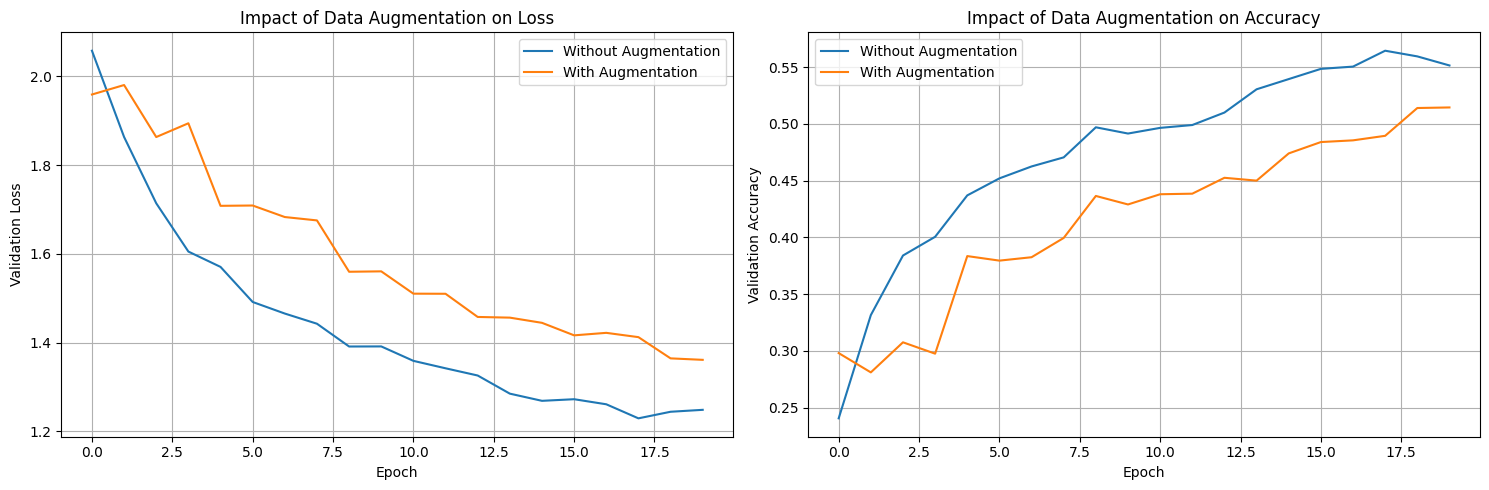

In [16]:
# Compare results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_no_aug.history['val_loss'], label='Without Augmentation')
axes[0].plot(history_with_aug.history['val_loss'], label='With Augmentation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Impact of Data Augmentation on Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_no_aug.history['val_accuracy'], label='Without Augmentation')
axes[1].plot(history_with_aug.history['val_accuracy'], label='With Augmentation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Impact of Data Augmentation on Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## PART 4: Computer Vision Tasks

### 4.1 Image Classification with Pre-trained Models

In [17]:
# Load pre-trained ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

resnet_classifier = ResNet50(weights='imagenet')

print("ResNet50 loaded for ImageNet classification!")
print(f"Input shape: {resnet_classifier.input_shape}")
print(f"Output classes: {resnet_classifier.output_shape[-1]}")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50 loaded for ImageNet classification!
Input shape: (None, 224, 224, 3)
Output classes: 1000


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step


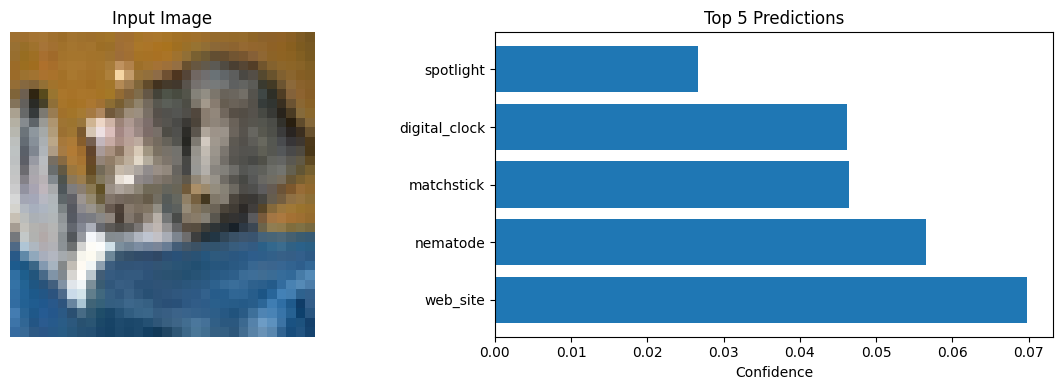


Top 5 Predictions:
1. web_site: 6.97%
2. nematode: 5.65%
3. matchstick: 4.64%
4. digital_clock: 4.61%
5. spotlight: 2.66%


In [18]:
# Create a sample image for classification (you can load your own)
# For demonstration, we'll use a CIFAR image resized
def classify_image(img_array, model):
    """Classify an image using pre-trained model"""
    # Resize to 224x224
    img_resized = cv2.resize(img_array, (224, 224))
    img_expanded = np.expand_dims(img_resized, axis=0)
    img_preprocessed = preprocess_input(img_expanded)
    
    # Predict
    predictions = model.predict(img_preprocessed, verbose=0)
    decoded = decode_predictions(predictions, top=5)[0]
    
    return decoded

# Example classification
sample_img = X_test[0]
predictions = classify_image(sample_img, resnet_classifier)

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 2, 2)
labels = [pred[1] for pred in predictions]
scores = [pred[2] for pred in predictions]
plt.barh(labels, scores)
plt.xlabel('Confidence')
plt.title('Top 5 Predictions')
plt.tight_layout()
plt.show()

print("\nTop 5 Predictions:")
for i, (imagenet_id, label, score) in enumerate(predictions):
    print(f"{i+1}. {label}: {score*100:.2f}%")

### 4.2 Feature Extraction and Visualization

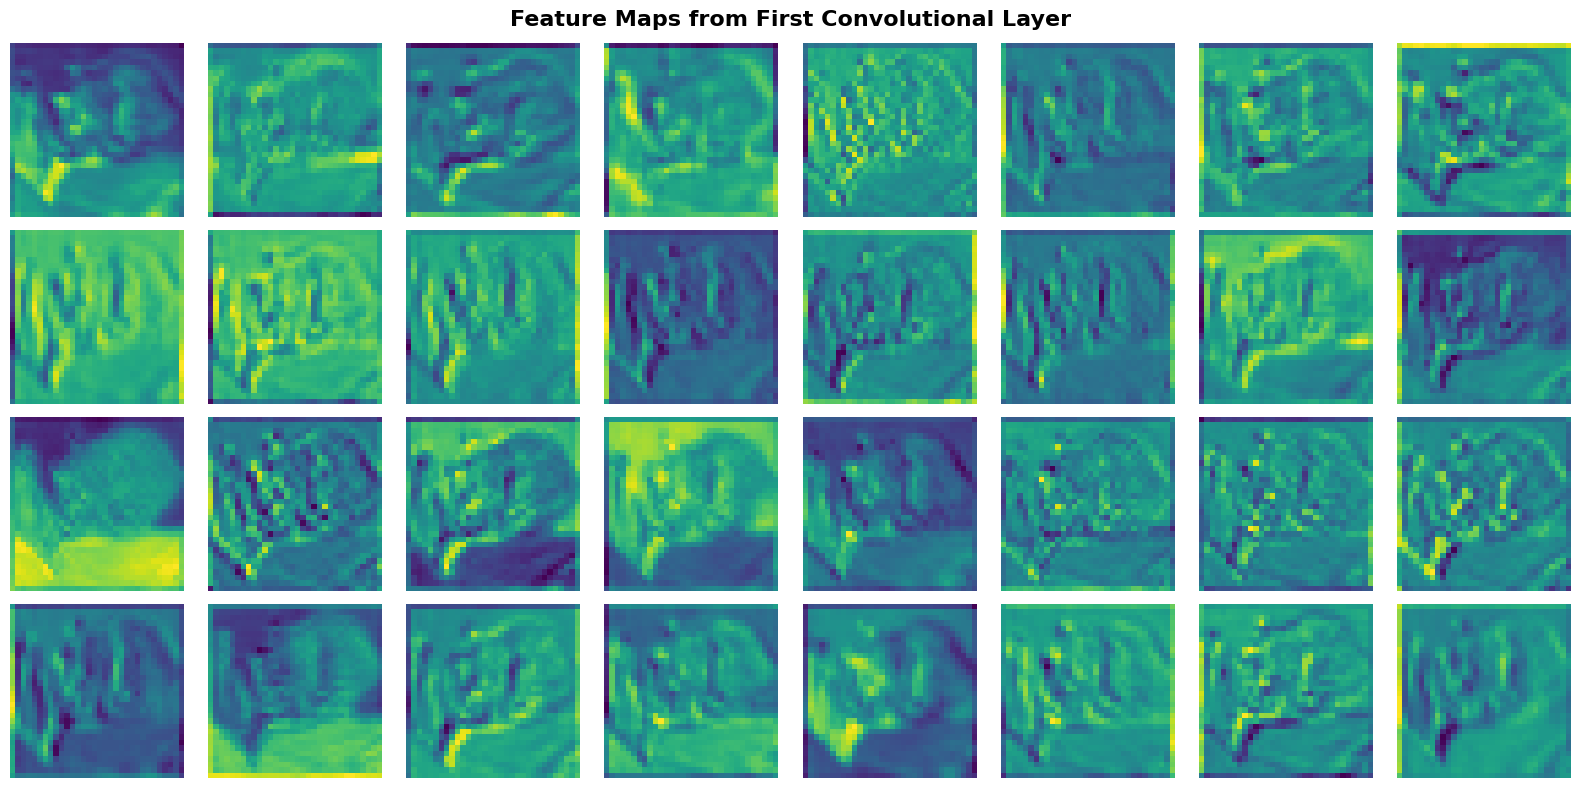

In [19]:
# Extract features from intermediate layers
from tensorflow.keras import Model

# Create feature extractor
feature_extractor = Model(
    inputs=resnet_model.inputs,
    outputs=[layer.output for layer in resnet_model.layers[:5]]
)

# Get feature maps
sample = np.expand_dims(X_test_subset[0], 0)
feature_maps = feature_extractor.predict(sample, verbose=0)

# Visualize first layer feature maps
first_layer_features = feature_maps[1]  # After first conv

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.ravel()

for i in range(32):
    axes[i].imshow(first_layer_features[0, :, :, i], cmap='viridis')
    axes[i].axis('off')

plt.suptitle('Feature Maps from First Convolutional Layer', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## PART 5: Object Detection with YOLO

### 5.1 Understanding Object Detection

In [21]:
# Install ultralytics for YOLOv8 (if not already installed)
# !pip install ultralytics

from ultralytics import YOLO
import urllib.request

print("YOLO library loaded!")
print("\nObject Detection vs Classification:")
print("• Classification: What is in the image?")
print("• Object Detection: What + Where (bounding boxes)")
print("• Instance Segmentation: What + Where + Exact shape")

YOLO library loaded!

Object Detection vs Classification:
• Classification: What is in the image?
• Object Detection: What + Where (bounding boxes)
• Instance Segmentation: What + Where + Exact shape


### 5.2 Load Pre-trained YOLO Model

In [22]:
# Load YOLOv8 pre-trained model
yolo_model = YOLO('yolov8n.pt')  # nano version for speed

print("YOLOv8 model loaded!")
print(f"Model: YOLOv8n (Nano - fastest)")
print(f"\nAvailable YOLO versions:")
print("• YOLOv8n: Fastest, smallest")
print("• YOLOv8s: Small")
print("• YOLOv8m: Medium")
print("• YOLOv8l: Large")
print("• YOLOv8x: Extra large, most accurate")

YOLOv8 model loaded!
Model: YOLOv8n (Nano - fastest)

Available YOLO versions:
• YOLOv8n: Fastest, smallest
• YOLOv8s: Small
• YOLOv8m: Medium
• YOLOv8l: Large
• YOLOv8x: Extra large, most accurate


### 5.3 Object Detection on Images


0: 640x480 4 persons, 1 bus, 64.1ms
Speed: 49.5ms preprocess, 64.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)


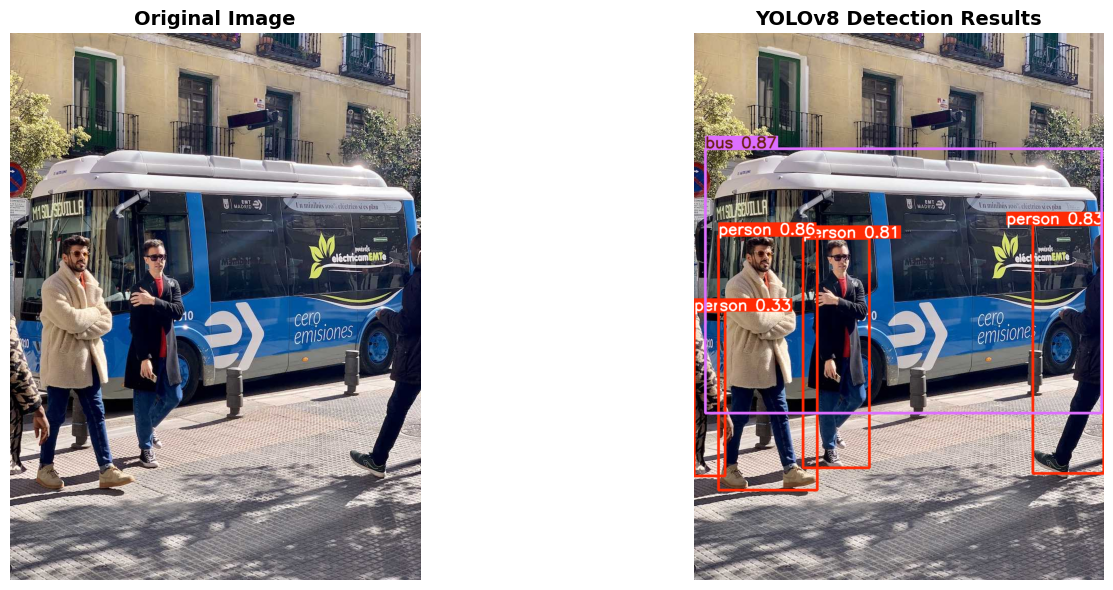


Detected Objects:
• bus: 86.77% confidence
• person: 86.40% confidence
• person: 83.26% confidence
• person: 81.13% confidence
• person: 33.41% confidence


In [23]:
# Download a sample image for detection
sample_url = "https://ultralytics.com/images/bus.jpg"
urllib.request.urlretrieve(sample_url, 'sample_image.jpg')

# Load image
img = cv2.imread('sample_image.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Run detection
results = yolo_model(img_rgb)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original image
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Detection results
result_img = results[0].plot()
axes[1].imshow(result_img)
axes[1].set_title('YOLOv8 Detection Results', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Print detection details
print("\nDetected Objects:")
for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        name = r.names[cls]
        print(f"• {name}: {conf*100:.2f}% confidence")

### 5.4 Real-Time Webcam Detection (Optional)

In [31]:
# Webcam detection (uncomment to run)
# WARNING: This will use your webcam!
import cv2
import time
import os, glob
print("Detected devices:", sorted(glob.glob("/dev/video*")))
from ultralytics import YOLO
yolo_model = YOLO('yolov8n.pt')  # or your preferred model


def webcam_detection(duration_seconds=10):
    """
    Run YOLO detection on webcam feed
    Press 'q' to quit
    """
    cap = cv2.VideoCapture(0)
    start_time = time.time()
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Run detection
        results = yolo_model(frame, verbose=False)
        
        # Plot results
        annotated_frame = results[0].plot()
        
        # Display
        cv2.imshow('YOLO Detection', annotated_frame)
        
        # Break on 'q' or after duration
        if cv2.waitKey(1) & 0xFF == ord('q') or (time.time() - start_time) > duration_seconds:
            break
    
    cap.release()
    cv2.destroyAllWindows()

# Uncomment to run webcam detection
webcam_detection(duration_seconds=30)

print("Webcam detection function defined.")
print("Uncomment the last line to run real-time detection!")

Detected devices: []
Webcam detection function defined.
Uncomment the last line to run real-time detection!


In [32]:
#!/usr/bin/env python3
"""
YOLO Object Detection on Video File
"""

import cv2
import urllib.request
import os
from pathlib import Path

print("Starting YOLO Video Detection...")
print("=" * 50)

# Download sample video
print("\nDownloading sample video...")
video_url = "https://sample-videos.com/video321/mp4/720/big_buck_bunny_720p_1mb.mp4"
video_path = "sample_video.mp4"

if not os.path.exists(video_path):
    try:
        urllib.request.urlretrieve(video_url, video_path)
        print(f"Video downloaded: {video_path}")
    except Exception as e:
        print(f"Download failed: {e}")
        print("Please manually download a video and update 'video_path' variable")
        exit(1)
else:
    print(f"Video already exists: {video_path}")

# Initialize YOLO model
print("\nLoading YOLO model...")
try:
    from ultralytics import YOLO
    yolo_model = YOLO('yolov8n.pt')
    print("YOLO model loaded")
except Exception as e:
    print(f"Failed to load YOLO: {e}")
    print("Install with: pip install ultralytics")
    exit(1)

# Process video
print("\nProcessing video with YOLO detection...")
print("=" * 50)

cap = cv2.VideoCapture(video_path)

# Get video properties
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video Info:")
print(f"   Resolution: {width}x{height}")
print(f"   FPS: {fps}")
print(f"   Total Frames: {total_frames}")
print()

# Setup output video
output_path = "output_detected.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Create output directory for frames
frames_dir = Path("detected_frames")
frames_dir.mkdir(exist_ok=True)

frame_count = 0
detected_objects = set()

print("Processing frames...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_count += 1
    
    # Run detection
    results = yolo_model(frame, verbose=False)
    
    # Get annotated frame
    annotated_frame = results[0].plot()
    
    # Collect detected classes
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        class_name = yolo_model.names[class_id]
        detected_objects.add(class_name)
    
    # Write to output video
    out.write(annotated_frame)
    
    # Save sample frames
    if frame_count % 30 == 0:
        sample_path = frames_dir / f"frame_{frame_count:04d}.jpg"
        cv2.imwrite(str(sample_path), annotated_frame)
    
    # Progress update
    if frame_count % 10 == 0:
        progress = (frame_count / total_frames) * 100
        print(f"   Progress: {progress:.1f}% ({frame_count}/{total_frames} frames)", end='\r')

print(f"\nProcessing complete")

# Cleanup
cap.release()
out.release()
cv2.destroyAllWindows()

# Summary
print("\n" + "=" * 50)
print("DETECTION SUMMARY")
print("=" * 50)
print(f"Output video: {output_path}")
print(f"Sample frames: {frames_dir}/")
print(f"Total frames: {frame_count}")
print(f"Detected objects: {', '.join(sorted(detected_objects)) if detected_objects else 'None'}")
print("\nTo view results:")
print(f"   vlc {output_path}")
print(f"   ls {frames_dir}/")
print("=" * 50)

Starting YOLO Video Detection...

Download failed: <urlopen error [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond>
Please manually download a video and update 'video_path' variable

Loading YOLO model...
YOLO model loaded

Processing video with YOLO detection...
Video Info:
   Resolution: 0x0
   FPS: 0
   Total Frames: 0

Processing frames...

Processing complete

DETECTION SUMMARY
Output video: output_detected.mp4
Sample frames: detected_frames/
Total frames: 0
Detected objects: None

To view results:
   vlc output_detected.mp4
   ls detected_frames/


### 5.5 Custom Object Detection Training

In [33]:
# Example: How to train YOLO on custom dataset
print("Training YOLO on Custom Dataset:\n")

print("1. Dataset Structure:")
print("""
dataset/
├── images/
│   ├── train/
│   └── val/
├── labels/
│   ├── train/
│   └── val/
└── data.yaml
""")

print("\n2. Label Format (YOLO format):")
print("<class_id> <x_center> <y_center> <width> <height>")
print("Example: 0 0.5 0.5 0.3 0.4")

print("\n3. Training Command:")
training_code = """
from ultralytics import YOLO

# Load pre-trained model
model = YOLO('yolov8n.pt')

# Train on custom dataset
results = model.train(
    data='dataset/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16
)
"""
print(training_code)

print("\n4. data.yaml example:")
yaml_example = """
path: /path/to/dataset
train: images/train
val: images/val

names:
  0: class1
  1: class2
  2: class3
"""
print(yaml_example)

Training YOLO on Custom Dataset:

1. Dataset Structure:

dataset/
├── images/
│   ├── train/
│   └── val/
├── labels/
│   ├── train/
│   └── val/
└── data.yaml


2. Label Format (YOLO format):
<class_id> <x_center> <y_center> <width> <height>
Example: 0 0.5 0.5 0.3 0.4

3. Training Command:

from ultralytics import YOLO

# Load pre-trained model
model = YOLO('yolov8n.pt')

# Train on custom dataset
results = model.train(
    data='dataset/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16
)


4. data.yaml example:

path: /path/to/dataset
train: images/train
val: images/val

names:
  0: class1
  1: class2
  2: class3



---
## PART 6: Practical Applications

### 6.1 Image Segmentation


0: 640x480 4 persons, 1 bus, 1 skateboard, 114.0ms
Speed: 3.3ms preprocess, 114.0ms inference, 157.9ms postprocess per image at shape (1, 3, 640, 480)


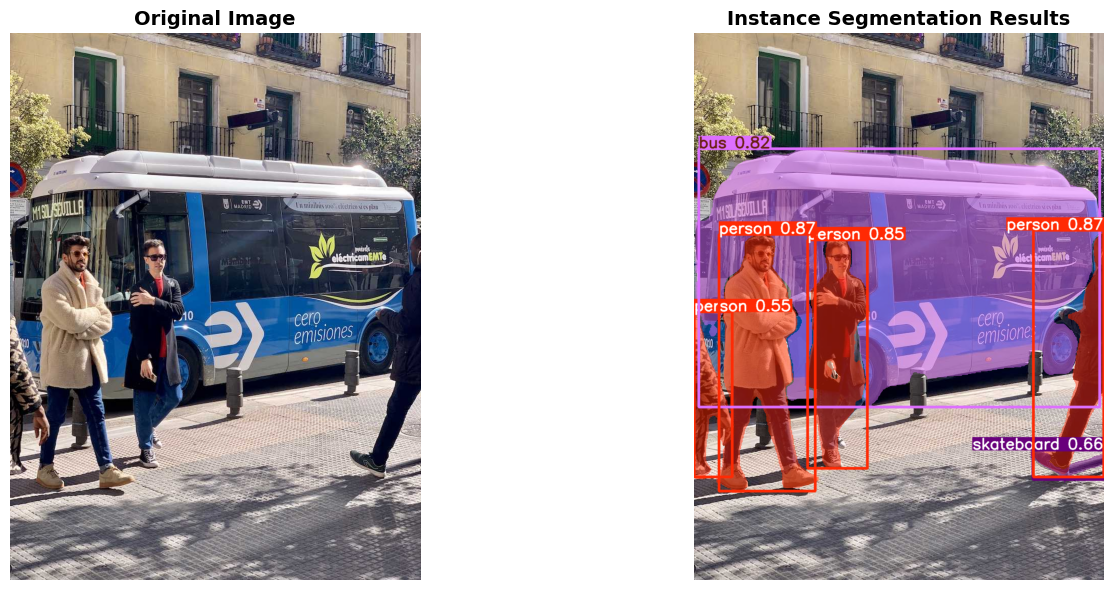

In [34]:
# Load YOLO segmentation model
seg_model = YOLO('yolov8n-seg.pt')

# Run segmentation
seg_results = seg_model(img_rgb)

# Display
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

seg_img = seg_results[0].plot()
axes[1].imshow(seg_img)
axes[1].set_title('Instance Segmentation Results', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 6.2 Pose Estimation


0: 384x640 2 persons, 115.1ms
Speed: 12.6ms preprocess, 115.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


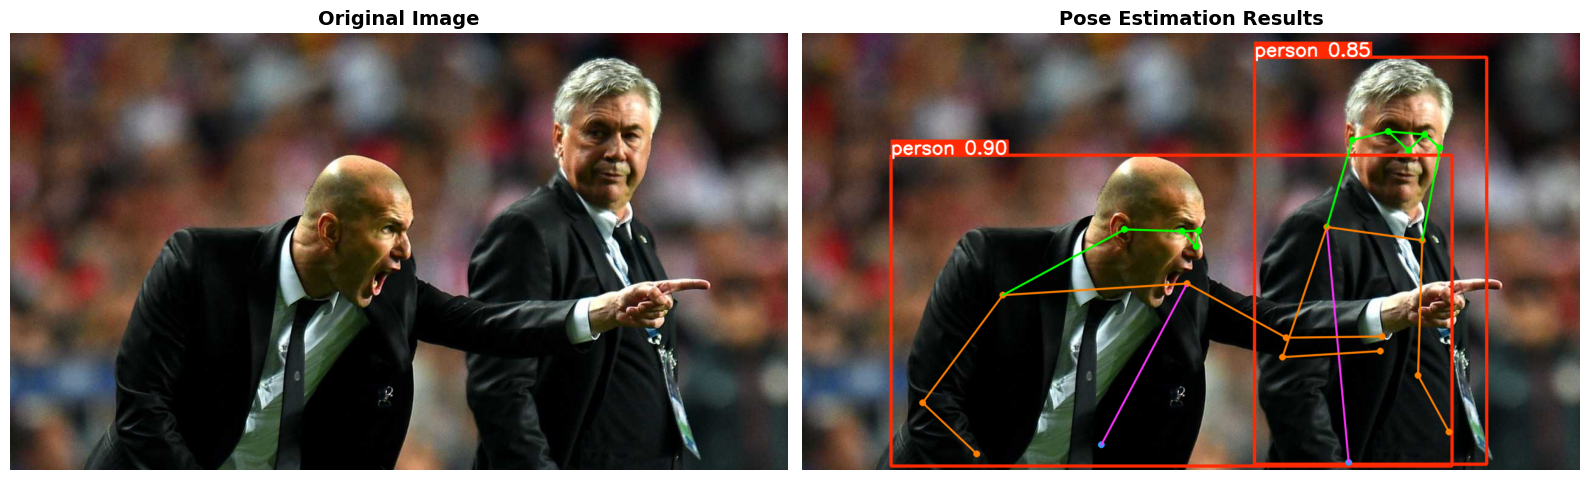

Detected keypoints: 17 body landmarks
• Nose, Eyes, Ears
• Shoulders, Elbows, Wrists
• Hips, Knees, Ankles


In [35]:
# Download sample image with people
pose_url = "https://ultralytics.com/images/zidane.jpg"
urllib.request.urlretrieve(pose_url, 'pose_image.jpg')

pose_img = cv2.imread('pose_image.jpg')
pose_img_rgb = cv2.cvtColor(pose_img, cv2.COLOR_BGR2RGB)

# Load pose model
pose_model = YOLO('yolov8n-pose.pt')

# Run pose estimation
pose_results = pose_model(pose_img_rgb)

# Display
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(pose_img_rgb)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

pose_plot = pose_results[0].plot()
axes[1].imshow(pose_plot)
axes[1].set_title('Pose Estimation Results', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Detected keypoints: 17 body landmarks")
print("• Nose, Eyes, Ears")
print("• Shoulders, Elbows, Wrists")
print("• Hips, Knees, Ankles")